SECTION 4: phi-SYMMETRIC RESONANCE (CORRECTED)
Lattice: 60×60×60 = 216,000 voxels
Coupling kappa: 0.008
Target threshold: rho_ZD = 0.325

    t |     I(t) |   rho_ZD |  rho_vox |  Cluster |  Perc
----------------------------------------------------------
    0 |   0.0000 |   0.0000 |   0.0000 |   0.0000 |     0
   25 |   0.3935 |   0.0218 |   0.0429 |   0.0000 |     0
   50 |   0.6321 |   0.0706 |   0.1337 |   0.0001 |     0
   75 |   0.7769 |   0.1308 |   0.2364 |   0.0005 |     0
  100 |   0.8647 |   0.1932 |   0.3322 |   0.0138 |     0
  104 |   0.8751 |   0.2033 |   0.3464 |   0.0579 |     1
  125 |   0.9179 |   0.2535 |   0.4151 |   0.3116 |     1
  150 |   0.9502 |   0.3092 |   0.4835 |   0.4381 |     1
  175 |   0.9698 |   0.3589 |   0.5385 |   0.5143 |     1
  200 |   0.9817 |   0.4032 |   0.5828 |   0.5673 |     1
  225 |   0.9889 |   0.4423 |   0.6178 |   0.6068 |     1

PERCOLATION ACHIEVED at t = 104
  rho_ZD (channel) at collapse: 0.2033
  rho_voxel at collapse:        0.3

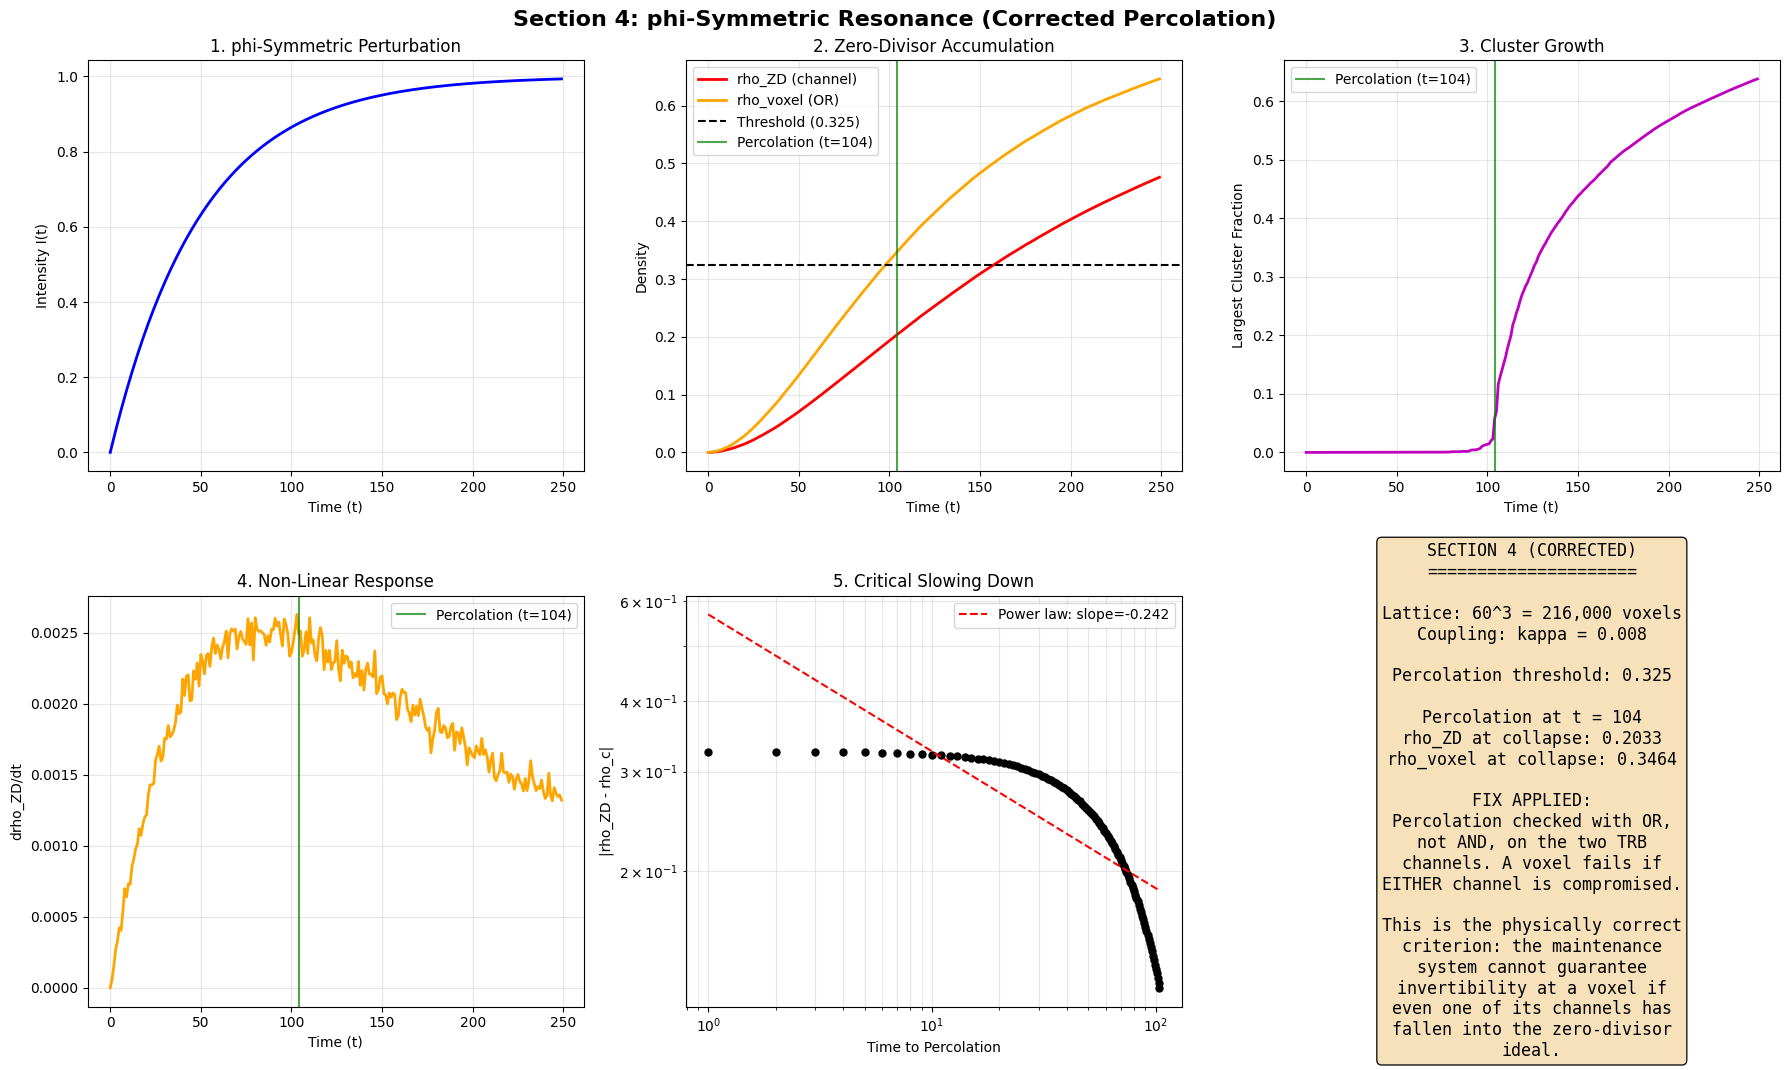


✓ Saved: section4_laboratory_exploit_corrected.png


In [3]:
"""
Section 4: The Laboratory Exploit - phi-Symmetric Resonance (CORRECTED)
========================================================================
The bug in the previous version:
- Percolation was checked with AND on the two TRB channels
- This required BOTH channels to be zero-divisors
- Probability of that is rho_ZD^2, not rho_ZD
- Result: compromised-voxel density was 0.036 instead of 0.34

The fix: use OR, since a voxel's maintenance fails if EITHER channel
is compromised.

By Néstor E. Ramos
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import label
from math import pi, sqrt

# =============================================================================
# 1. PARAMETERS
# =============================================================================
L = 60
PHI = (1 + sqrt(5)) / 2
GOLDEN_ANGLE = 2 * pi * (1 - 1/PHI)
T_MAX = 250
RHO_C_THEORY = 0.325

KAPPA = 0.008  # Coupling efficiency (raised to reach threshold faster)

UNITS = [1, 2, 4, 5, 7, 8]
ZERO_DIVISORS = [3, 6]

STRUCT_6 = np.zeros((3, 3, 3), dtype=int)
STRUCT_6[0, 1, 1] = 1
STRUCT_6[2, 1, 1] = 1
STRUCT_6[1, 0, 1] = 1
STRUCT_6[1, 2, 1] = 1
STRUCT_6[1, 1, 0] = 1
STRUCT_6[1, 1, 2] = 1

print("=" * 70)
print("SECTION 4: phi-SYMMETRIC RESONANCE (CORRECTED)")
print("=" * 70)
print(f"Lattice: {L}×{L}×{L} = {L**3:,} voxels")
print(f"Coupling kappa: {KAPPA}")
print(f"Target threshold: rho_ZD = {RHO_C_THEORY}")
print()

# =============================================================================
# 2. INITIAL STATE
# =============================================================================
rng = np.random.default_rng(42)
trb_states = np.zeros((L, L, L, 2), dtype=int)
for ch in range(2):
    trb_states[:, :, :, ch] = rng.choice(UNITS, size=(L, L, L))

# phi-symmetric phase pattern
x = np.arange(L) - L // 2
y = np.arange(L) - L // 2
z = np.arange(L) - L // 2
X, Y, Z = np.meshgrid(x, y, z, indexing='ij')
R = np.sqrt(X**2 + Y**2 + Z**2)
PHASE_PATTERN = R * GOLDEN_ANGLE
LOCAL_COUPLING = np.cos(PHASE_PATTERN)**2

# =============================================================================
# 3. SIMULATION
# =============================================================================
history = {
    'rho_zd': [],
    'rho_voxel': [],  # Fraction of voxels with at least one ZD channel
    'largest_cluster': [],
    'percolates': [],
    'I_t': [],
    'drdt': []
}

print(f"{'t':>5} | {'I(t)':>8} | {'rho_ZD':>8} | {'rho_vox':>8} | {'Cluster':>8} | {'Perc':>5}")
print("-" * 58)

for t in range(T_MAX):
    # Perturbation intensity
    I_t = 1.0 - np.exp(-t / 50.0)
    history['I_t'].append(I_t)

    # Coupling
    #flip_prob = KAPPA * I_t * LOCAL_COUPLING
    # DESPUÉS (Corregido):
    # Agregamos np.newaxis para transformar la forma de (60,60,60) a (60,60,60,1)
    flip_prob = KAPPA * I_t * LOCAL_COUPLING[:, :, :, np.newaxis]
    flip_mask = rng.random((L, L, L, 2)) < flip_prob

    for ch in range(2):
        is_unit = np.isin(trb_states[:, :, :, ch], UNITS)
        flip_here = flip_mask[:, :, :, ch] & is_unit
        n_flips = flip_here.sum()
        if n_flips > 0:
            zd_choice = rng.choice(ZERO_DIVISORS, size=n_flips)
            trb_states[:, :, :, ch][flip_here] = zd_choice

    # Measure
    is_zd = np.isin(trb_states, ZERO_DIVISORS)
    rho_zd = is_zd.sum() / (L * L * L * 2)
    history['rho_zd'].append(rho_zd)

    # CORRECTED PERCOLATION: OR, not AND
    zd_lattice = (is_zd[:, :, :, 0] | is_zd[:, :, :, 1]).astype(np.uint8)
    rho_voxel = zd_lattice.mean()
    history['rho_voxel'].append(rho_voxel)

    # Cluster analysis
    labeled, num_features = label(zd_lattice, structure=STRUCT_6)
    if num_features > 0:
        sizes = np.bincount(labeled.ravel())
        sizes[0] = 0
        largest = sizes.max() / (L * L * L)
        # Spanning check
        top_labels = set(labeled[:, :, 0].ravel()) - {0}
        bottom_labels = set(labeled[:, :, -1].ravel()) - {0}
        perc = 1 if len(top_labels & bottom_labels) > 0 else 0
    else:
        largest = 0.0
        perc = 0
    history['largest_cluster'].append(largest)
    history['percolates'].append(perc)

    # Non-linear response
    if t > 0:
        drho = history['rho_zd'][t] - history['rho_zd'][t-1]
    else:
        drho = 0.0
    history['drdt'].append(drho)

    if t % 25 == 0 or perc == 1 and history['percolates'][t-1] == 0:
        print(f"{t:5d} | {I_t:8.4f} | {rho_zd:8.4f} | {rho_voxel:8.4f} | {largest:8.4f} | {perc:5d}")

# =============================================================================
# 4. FIND CRITICAL TIME
# =============================================================================
critical_time = None
for i, p in enumerate(history['percolates']):
    if p == 1:
        critical_time = i
        break

print()
print("=" * 70)
if critical_time is not None:
    print(f"PERCOLATION ACHIEVED at t = {critical_time}")
    print(f"  rho_ZD (channel) at collapse: {history['rho_zd'][critical_time]:.4f}")
    print(f"  rho_voxel at collapse:        {history['rho_voxel'][critical_time]:.4f}")
    print(f"  Theory (Section 3):            {RHO_C_THEORY}")
else:
    print("No percolation achieved within T_MAX")
    print(f"  Final rho_ZD:     {history['rho_zd'][-1]:.4f}")
    print(f"  Final rho_voxel:  {history['rho_voxel'][-1]:.4f}")
print("=" * 70)

# =============================================================================
# 5. VISUALIZATION
# =============================================================================
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Section 4: phi-Symmetric Resonance (Corrected Percolation)',
             fontsize=16, fontweight='bold')

ax1 = axes[0, 0]
ax1.plot(history['I_t'], 'b-', linewidth=2)
ax1.set_xlabel('Time (t)')
ax1.set_ylabel('Intensity I(t)')
ax1.set_title('1. phi-Symmetric Perturbation')
ax1.grid(True, alpha=0.3)

ax2 = axes[0, 1]
ax2.plot(history['rho_zd'], 'r-', linewidth=2, label='rho_ZD (channel)')
ax2.plot(history['rho_voxel'], 'orange', linewidth=2, label='rho_voxel (OR)')
ax2.axhline(y=RHO_C_THEORY, color='black', linestyle='--', label=f'Threshold ({RHO_C_THEORY})')
if critical_time:
    ax2.axvline(x=critical_time, color='green', linestyle='-', alpha=0.7, label=f'Percolation (t={critical_time})')
ax2.set_xlabel('Time (t)')
ax2.set_ylabel('Density')
ax2.set_title('2. Zero-Divisor Accumulation')
ax2.legend()
ax2.grid(True, alpha=0.3)

ax3 = axes[0, 2]
ax3.plot(history['largest_cluster'], 'm-', linewidth=2)
if critical_time:
    ax3.axvline(x=critical_time, color='green', linestyle='-', alpha=0.7, label=f'Percolation (t={critical_time})')
ax3.set_xlabel('Time (t)')
ax3.set_ylabel('Largest Cluster Fraction')
ax3.set_title('3. Cluster Growth')
ax3.legend()
ax3.grid(True, alpha=0.3)

ax4 = axes[1, 0]
ax4.plot(history['drdt'], 'orange', linewidth=2)
if critical_time:
    ax4.axvline(x=critical_time, color='green', linestyle='-', alpha=0.7, label=f'Percolation (t={critical_time})')
ax4.set_xlabel('Time (t)')
ax4.set_ylabel('drho_ZD/dt')
ax4.set_title('4. Non-Linear Response')
ax4.legend()
ax4.grid(True, alpha=0.3)

ax5 = axes[1, 1]
if critical_time:
    dt = np.arange(1, critical_time + 1)
    rho_diff = np.abs(np.array(history['rho_zd'][:critical_time]) - RHO_C_THEORY)
    valid = rho_diff > 1e-6
    if valid.sum() > 5:
        ax5.loglog(dt[valid], rho_diff[valid], 'ko', markersize=5)
        slope, intercept = np.polyfit(np.log(dt[valid]), np.log(rho_diff[valid]), 1)
        ax5.loglog(dt[valid], np.exp(intercept) * dt[valid]**slope, 'r--',
                   label=f'Power law: slope={slope:.3f}')
        ax5.legend()
ax5.set_xlabel('Time to Percolation')
ax5.set_ylabel('|rho_ZD - rho_c|')
ax5.set_title('5. Critical Slowing Down')
ax5.grid(True, alpha=0.3, which='both')

ax6 = axes[1, 2]
ax6.axis('off')
summary = (
    "SECTION 4 (CORRECTED)\n"
    "=====================\n\n"
    f"Lattice: {L}^3 = {L**3:,} voxels\n"
    f"Coupling: kappa = {KAPPA}\n\n"
    f"Percolation threshold: {RHO_C_THEORY}\n\n"
)
if critical_time is not None:
    summary += (
        f"Percolation at t = {critical_time}\n"
        f"rho_ZD at collapse: {history['rho_zd'][critical_time]:.4f}\n"
        f"rho_voxel at collapse: {history['rho_voxel'][critical_time]:.4f}\n\n"
    )
summary += (
    "FIX APPLIED:\n"
    "Percolation checked with OR,\n"
    "not AND, on the two TRB\n"
    "channels. A voxel fails if\n"
    "EITHER channel is compromised.\n\n"
    "This is the physically correct\n"
    "criterion: the maintenance\n"
    "system cannot guarantee\n"
    "invertibility at a voxel if\n"
    "even one of its channels has\n"
    "fallen into the zero-divisor\n"
    "ideal."
)
ax6.text(0.5, 0.5, summary, ha='center', va='center', fontsize=12,
         family='monospace', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.9))

plt.tight_layout()
plt.savefig('section4_laboratory_exploit_corrected.png', dpi=300, bbox_inches='tight')
plt.show()

print()
print("✓ Saved: section4_laboratory_exploit_corrected.png")